# Задание 1. Пропущенные значения и корреляции

## 1. Создание синтетического датасета  
Используя функцию multivariate_normal из numpy с любым random_state,
сгенерировать и зафиксировать датасет dfS00, в котором есть четыре количественных
(недискретных) признака и 1 класс размером 1000 объектов, для одной пары признаков
(A и B) которого задана корреляция r=+0.9, а остальные признаки не сопряжены друг с
другом.

In [1]:
import numpy as np
import pandas as pd

# Типо нормальное распределение

mean = [0, 0, 0, 0]  # средние значения
cov = [
    [1.0, 0.9, 0.0, 0.0],  # A коррелирует с B
    [0.9, 1.0, 0.0, 0.0],  # B коррелирует с A
    [0.0, 0.0, 1.0, 0.0],  # C независим
    [0.0, 0.0, 0.0, 1.0]   # D независим
] 

np.random.seed(42)  # фиксируем random_state
data = np.random.multivariate_normal(mean, cov, size=1000) # генерирует выборку из многомерного нормального распределения
dfS00 = pd.DataFrame(data, columns=['A', 'B', 'C', 'D'])
dfS00['class'] = (np.random.random(len(dfS00)) > 0.5).astype(int)
display(dfS00.head(5))

,A,B,C,D,class
0,-0.824697,-0.143577,0.647689,-0.138264,0
1,0.056621,0.399828,1.579213,-0.234137,0
2,0.561727,0.353447,-0.463418,0.542560,1
3,-0.110104,-0.361567,-1.724918,-1.913280,1
4,1.302986,0.671385,-0.908024,0.314247,1


## 2. Статистика по датасету
Вывести в табличной форме статистику по датасету:
- Размерность всего датасета (объекты и признаки)  
- Тип каждого признака 
- Количество классов и объектов в каждом из классов  
- Иные оценки выборки 
- Число объектов с NaN по классам  
- Число объектов с 0 по классам 

In [2]:
# Размерность всего датасета (объекты и признаки) 
print(f'Размерность датасета: {dfS00.shape}\n')


# Тип каждого признака
print(f'Тип каждого признака: \n{dfS00.dtypes}\n')


# Количество классов и объектов в каждом из классов
counts = dfS00['class'].value_counts().sort_index()
print('Количество классов:', dfS00['class'].nunique())
print('Объектов в каждом классе:')
print(f'{counts}\n')


# Иные оценки выборки
def describe_extended(series):
    x = series.values
    
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1

    return pd.Series({
        'mean': np.mean(x),
        'median': np.median(x),
        'std': np.std(x, ddof=1),
        'var': np.var(x, ddof=1),
        'min': np.min(x),
        'max': np.max(x),
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
    })
stats_table = dfS00.drop(columns=['class']).apply(describe_extended)
print('Различные оценки выборки: ')
print(stats_table.T.round(3), '\n')

Размерность датасета: (1000, 5)

Тип каждого признака: 
A        float64
B        float64
C        float64
D        float64
class      int64
dtype: object

Количество классов: 2
Объектов в каждом классе:
class
0    508
1    492
Name: count, dtype: int64

Различные оценки выборки: 
    mean  median    std    var    min    max     q1     q3    iqr
A -0.037  -0.039  0.961  0.924 -3.137  3.198 -0.657  0.600  1.257
B -0.023  -0.032  0.971  0.943 -3.185  3.220 -0.693  0.600  1.293
C -0.008  -0.008  1.006  1.012 -3.241  3.152 -0.675  0.642  1.318
D  0.025   0.020  1.012  1.024 -2.896  3.853 -0.677  0.694  1.371 



In [3]:
# Число объектов с NaN по классам
print('Число объектов с NaN по классам: ')
print(dfS00.groupby('class').apply(lambda g: g.isna().any(axis=1).sum()))


# Число объектов с 0 по классам
print('\nЧисло объектов с 0 по классам: ')
features = [c for c in dfS00.columns if c != 'class']
print(dfS00.groupby('class')[features].apply(lambda g: (g == 0).any(axis=1).sum()))


Число объектов с NaN по классам: 
class
0    0
1    0
dtype: int64

Число объектов с 0 по классам: 
class
0    0
1    0
dtype: int64


## 3. Визуализация статистики в 1D
- Выполнить 1D визуализацию датасета по каждому из признаков в форме raincloud plot with jittering,
- В виде boxplot отобразить медианы, межквартильные размахи (IQR) и размахи (Range), с параметрами boxplot, которые можно заменять на другие оценки выборки.

/tmp/ipykernel_13089/1439370909.py:70: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_13089/1439370909.py:70: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_13089/1439370909.py:70: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_13089/1439370909.py:70: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


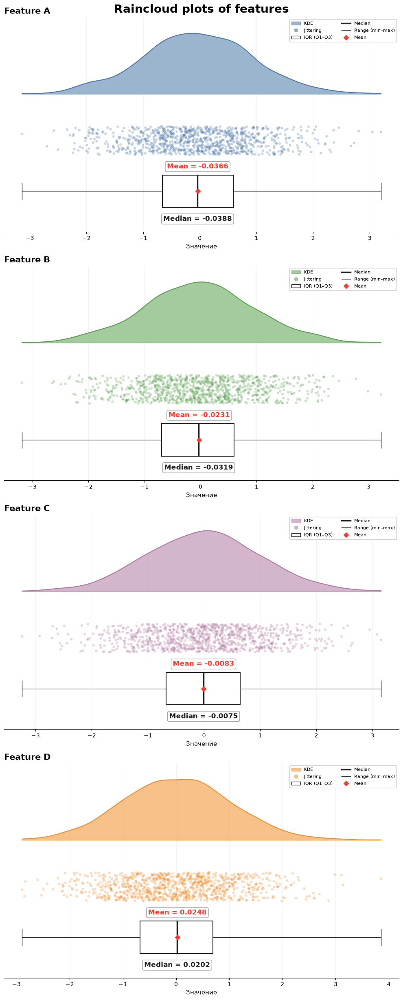

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def _adaptive_style(n):
    if n <= 30: return 0.95, 35
    if n <= 100: return 0.75, 30
    if n <= 500: return 0.5, 25
    if n <= 2000: return 0.3, 20
    if n <= 10000: return 0.20, 15
    return 0.1, 10

def _raincloud_legend(color):
    return [
        Patch(facecolor=color, edgecolor=color, alpha=0.55, label='KDE'),
        Line2D([0], [0], marker='o', color='none', markerfacecolor=color,
               markeredgecolor='none', markersize=7, alpha=0.6, label='Jittering'),
        Patch(facecolor='white', edgecolor='#222222', label='IQR (Q1–Q3)'),
        Line2D([0], [0], color='#222222', linewidth=2.5, label='Median'),
        Line2D([0], [0], color='#222222', linewidth=1, label='Range (min–max)'),
        Line2D([0], [0], marker='D', color='none', markerfacecolor='#FF3B30',
               markeredgecolor='#FF3B30', markersize=6, label='Mean')
    ]

def plot_raincloud(df, feature, color, ax, whis=(0, 100), show_mean=True):
    x = df[feature].dropna().to_numpy()
    n = x.size
    scatter_alpha, scatter_size = _adaptive_style(n)

    # KDE
    if n > 1 and np.ptp(x) > 0:
        kde = gaussian_kde(x)
        xx = np.linspace(x.min(), x.max(), 400)
        yy = kde(xx)
        yy = yy / yy.max() * 0.30
        cloud_y = 0.2

        ax.fill_between(
            xx, cloud_y, cloud_y + yy,
            color=color,
            alpha=0.55,
            zorder=1
        )
        ax.plot(
            xx, cloud_y + yy,
            color=color,
            linewidth=1.5,
            zorder=2
        )

    # Jittering
    rng = np.random.default_rng(42)
    y_jitter = rng.uniform(-0.07, 0.07, size=n)

    ax.scatter(
        x,
        y_jitter - 0.03,
        color=color,
        alpha=scatter_alpha,
        s=scatter_size,
        edgecolors='none',
        zorder=3
    )
    mean_value = np.mean(x)
    median_value = np.median(x)
    
    # Boxplot: IQR, Median, Range, Mean
    ax.boxplot(
        x,
        vert=False,
        positions=[-0.28],
        widths=0.16,
        whis=whis,
        showfliers=False,
        showmeans=show_mean,
        patch_artist=True,
        meanprops={
            'marker': 'D',
            'markerfacecolor': '#FF3B30',
            'markeredgecolor': '#FF3B30',
            'markersize': 6
        },
        medianprops={
            'color': '#222222',
            'linewidth': 2.5
        },
        boxprops={
            'facecolor': 'white',
            'edgecolor': '#222222',
            'linewidth': 1.5
        },
        whiskerprops={
            'color': '#222222',
            'linewidth': 1
        },
        capprops={
            'color': '#222222',
            'linewidth': 1
        }
    )
    
    ax.text(
        mean_value,
        -0.175,
        f'Mean = {mean_value:.4f}',
        color='#FF3B30',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='bottom',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='#999999',
            alpha=0.9
        )
    )

    ax.text(
        median_value,
        -0.4,
        f'Median = {median_value:.4f}',
        color='#222222',
        fontsize=12,
        fontweight='bold',
        ha='center',
        va='top',
        bbox=dict(
            boxstyle='round,pad=0.25',
            facecolor='white',
            edgecolor='#999999',
            alpha=0.9
        )
    )

    ax.set_title(f'Feature {feature}', fontsize=15, fontweight='bold', loc='left')
    ax.set_xlabel('Значение', fontsize=11)
    ax.set_yticks([])
    ax.set_ylim(-0.48, 0.58)
    ax.grid(axis='x', alpha=0.15)
    ax.spines[['left', 'right', 'top']].set_visible(False)

    ax.legend(
        handles=_raincloud_legend(color),
        loc='upper right',
        ncol=2,
        frameon=True,
        fontsize=8,
        framealpha=0.9
    )

features = ['A', 'B', 'C', 'D']
kde_colors = ['#4C78A8', '#59A14F', '#B07AA1', '#F28E2B']

fig, axes = plt.subplots(4, 1, figsize=(10, 25),sharex=False)

for ax, feature, color in zip(axes, features, kde_colors):
    plot_raincloud(dfS00, feature, color, ax, whis=(0, 100), show_mean=True)

fig.suptitle('Raincloud plots of features', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Вызуализация статистики в 2D
Выполнить  2D  визуализацию  датасета  по  всем  парам  выбранных  переменных  с использованием scatterplot с параметрами визуализации, регулируемыми пользователем:
1. Цвета  и  толщины  осей
2. Число/шаг  больших  и  малых  рисок  осей
3. Сетка  пространства
4. Квадратность  формы  каждого  рисунка
5. Размер  и  тип  шрифтов  каждого  типа  подписей
6. Отключаемость легенд и заглавий
7. Прозрачность объектов, на которых отображены: 
- на графиках разных пар признаков объекты классов разными по форме/цвету точками
- на графиках с одной и той же парой переменных 
- диаграммы плотности распределения каждого класса по оси признака разными по цвету/прозрачности.

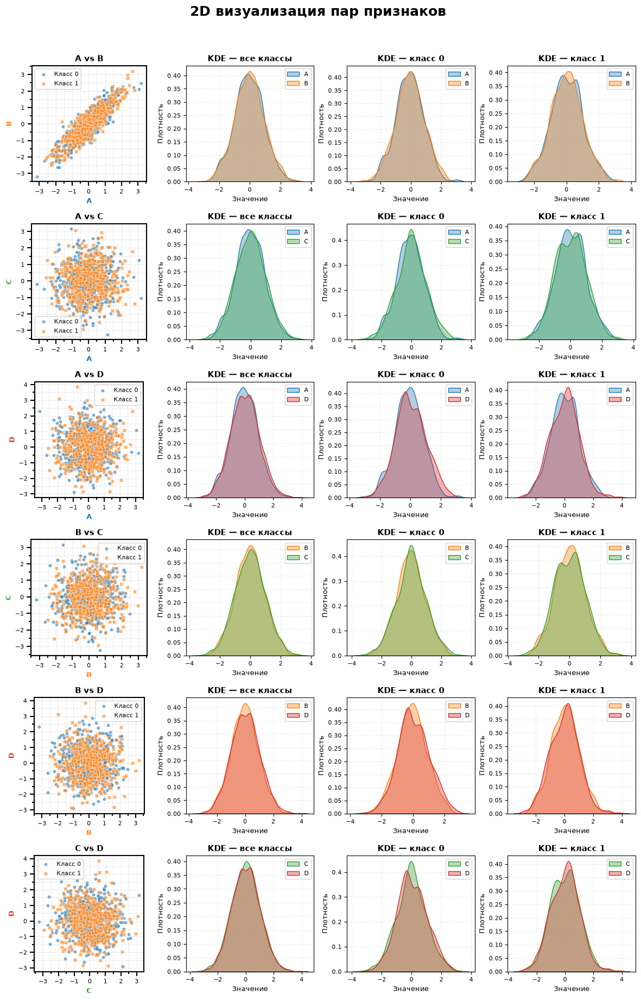

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from itertools import combinations
from matplotlib.ticker import MultipleLocator

# Фиксируем цвета для признаков
FEATURE_COLORS = {
    'A': '#1f77b4',
    'B': '#ff7f0e',
    'C': '#2ca02c',
    'D': '#d62728'
}

def plot_pair(
    df, x, y,
    ax_scatter, ax_kde, ax_kde_0, ax_kde_1,
    point_size=30, point_alpha=0.6,
    axis_color='black', axis_width=1.5,
    major_step=1, minor_step=0.5,
    show_grid=True, aspect_equal=True,
    title_size=12, label_size=10, tick_size=9,
    font='sans-serif', kde_alpha=0.35, kde_bw=0.8,
    show_legend=True, show_title=True
):
    classes = sorted(df['class'].dropna().unique())
    class_colors = sns.color_palette('tab10', len(classes))
    markers = ['o', 's', '^', 'D', 'v'][:len(classes)]

    color_x = FEATURE_COLORS[x]
    color_y = FEATURE_COLORS[y]

    # 1. Scatterplot
    for i, cls in enumerate(classes):
        data = df[df['class'] == cls]

        ax_scatter.scatter(
            data[x], data[y],
            color=class_colors[i],
            marker=markers[i],
            s=point_size,
            alpha=point_alpha,
            label=f'Класс {cls}',
            edgecolor='white',
            linewidth=0.5
        )

    ax_scatter.set_xlabel(
        x,
        fontsize=label_size,
        fontfamily=font,
        color=color_x,
        fontweight='bold'
    )

    ax_scatter.set_ylabel(
        y,
        fontsize=label_size,
        fontfamily=font,
        color=color_y,
        fontweight='bold'
    )

    if show_title:
        ax_scatter.set_title(
            f'{x} vs {y}',
            fontsize=title_size,
            fontfamily=font,
            fontweight='bold'
        )
        
    if show_legend:
        ax_scatter.legend(fontsize=tick_size, loc='best', framealpha=0.8)

    if aspect_equal:
        ax_scatter.set_aspect('equal', adjustable='box')

    ax_scatter.xaxis.set_major_locator(MultipleLocator(major_step))
    ax_scatter.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax_scatter.yaxis.set_major_locator(MultipleLocator(major_step))
    ax_scatter.yaxis.set_minor_locator(MultipleLocator(minor_step))

    ax_scatter.tick_params(
        axis='both',
        which='major',
        length=6,
        width=axis_width,
        labelsize=tick_size,
        colors=axis_color
    )

    ax_scatter.tick_params(
        axis='both',
        which='minor',
        length=3,
        width=axis_width,
        colors=axis_color
    )

    for spine in ax_scatter.spines.values():
        spine.set_color(axis_color)
        spine.set_linewidth(axis_width)

    if show_grid:
        ax_scatter.grid(True, which='both', alpha=0.3, linestyle='--')

    # Общие параметры KDE
    def make_kde(ax, data, title):
        sns.kdeplot(
            data=data, x=x, ax=ax,
            color=color_x, fill=True,
            alpha=kde_alpha,
            bw_adjust=kde_bw,
            label=x
        )

        sns.kdeplot(
            data=data, x=y, ax=ax,
            color=color_y, fill=True,
            alpha=kde_alpha,
            bw_adjust=kde_bw,
            label=y
        )

        if show_title:
            ax.set_title(title, fontsize=title_size, fontfamily=font, fontweight='bold')

        ax.set_xlabel('Значение', fontsize=label_size, fontfamily=font)
        ax.set_ylabel('Плотность', fontsize=label_size,fontfamily=font)

        if show_legend:
            ax.legend(fontsize=tick_size, framealpha=0.8)

        ax.grid(True, alpha=0.2, linestyle='--')
        ax.tick_params(labelsize=tick_size)

    # 2. KDE всех классов
    make_kde(ax_kde, df, 'KDE — все классы')

    # 3. KDE класса 0
    make_kde(ax_kde_0, df[df['class'] == 0], 'KDE — класс 0')

    # 4. KDE класса 1
    make_kde(ax_kde_1, df[df['class'] == 1], 'KDE — класс 1')


# Построение всех пар
features = ['A', 'B', 'C', 'D']
pairs = list(combinations(features, 2))

fig, axes = plt.subplots(len(pairs), 4, figsize=(12, 3 * len(pairs)))

for i, (x, y) in enumerate(pairs):
    ax_scatter = axes[i, 0]
    ax_kde = axes[i, 1]
    ax_kde_0 = axes[i, 2]
    ax_kde_1 = axes[i, 3]

    plot_pair(
        dfS00, x, y,
        ax_scatter, ax_kde, ax_kde_0, ax_kde_1,
        point_size=20,
        point_alpha=0.6,
        axis_color='black',
        axis_width=1.5,
        major_step=1,
        minor_step=0.5,
        show_grid=True,
        aspect_equal=True,
        title_size=11,
        label_size=9,
        tick_size=8,
        font='sans-serif',
        kde_alpha=0.35,
        kde_bw=0.8,
        show_legend=True, 
        show_title=True
    )

fig.suptitle(
    '2D визуализация пар признаков',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

## 5. Оценка степени сопряженности
Используя  коэффициенты  корреляции  Пирсона  и  Спирмана,  в  форме  heat-map таблицы оценить степень сопряженности пар признаков-переменных: 
- на всем датасете    
- в каждом отдельном классе датасета

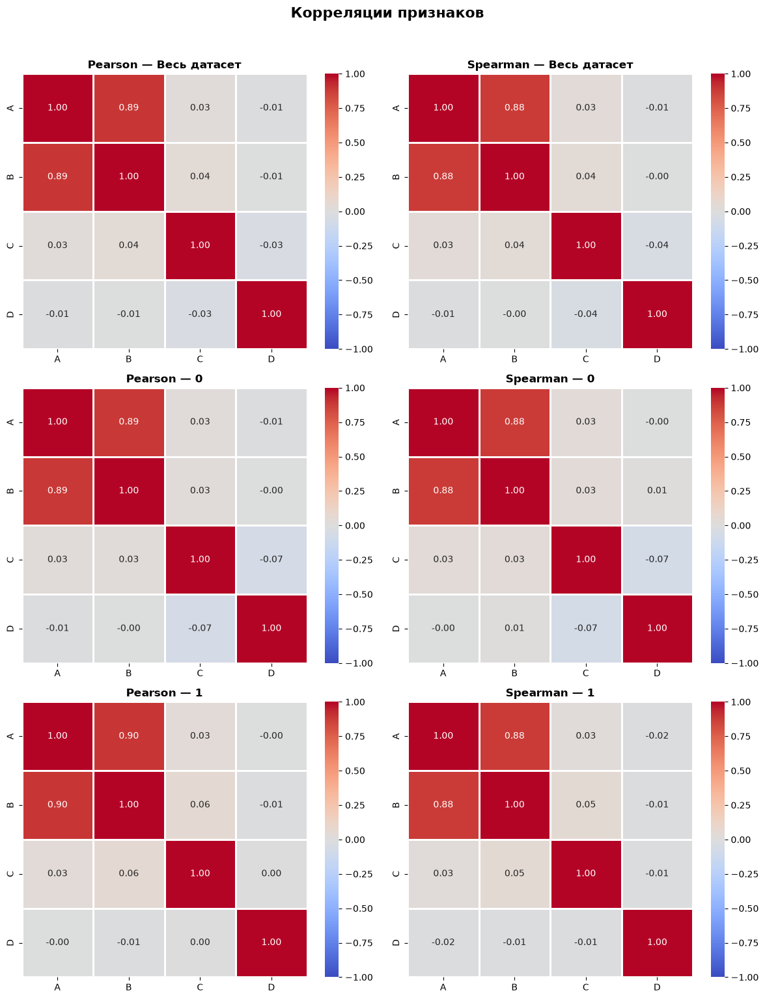

In [6]:
def plot_correlation_heatmaps(df, features):
    groups = [('Весь датасет', df)] + list(df.groupby('class'))

    fig, axes = plt.subplots(len(groups), 2, figsize=(12, 5 * len(groups)))
    axes = np.atleast_2d(axes)

    for i, (name, data) in enumerate(groups):
        for j, method in enumerate(['pearson', 'spearman']):
            corr = data[features].corr(method=method)
            sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                        fmt='.2f', linewidths=1, linecolor='white', ax=axes[i, j])
            axes[i, j].set_title(f'{method.capitalize()} — {name}', fontsize=12, fontweight='bold')

    fig.suptitle('Корреляции признаков', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

plot_correlation_heatmaps(dfS00, features)



## 6. Случайное удаление значения
- На  основе  исходного  датасета  dfS00 клонировать набор  датасетов dfSdXX,  в которых из  исходного  датасета  случайным  образом  удалено  значение  заданного пользователем  числа  ячеек  (0%,  1%,  2%,  5%,  10%,  20%,  50%,  80%)
- Для  выбираемой пары признаков (исходно A+B)  визуализировать каждый датасет dfSdXX  как панно mxn рисунков scatterplot. 

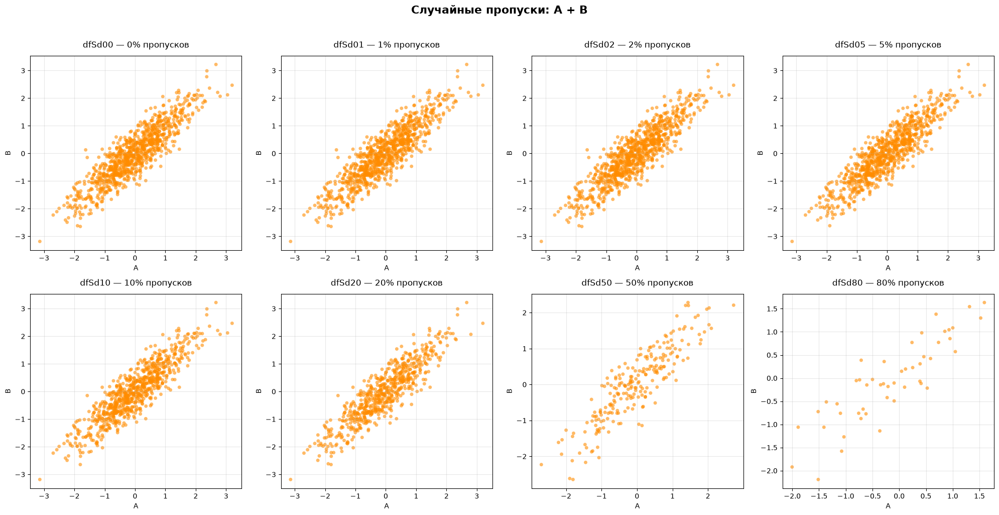

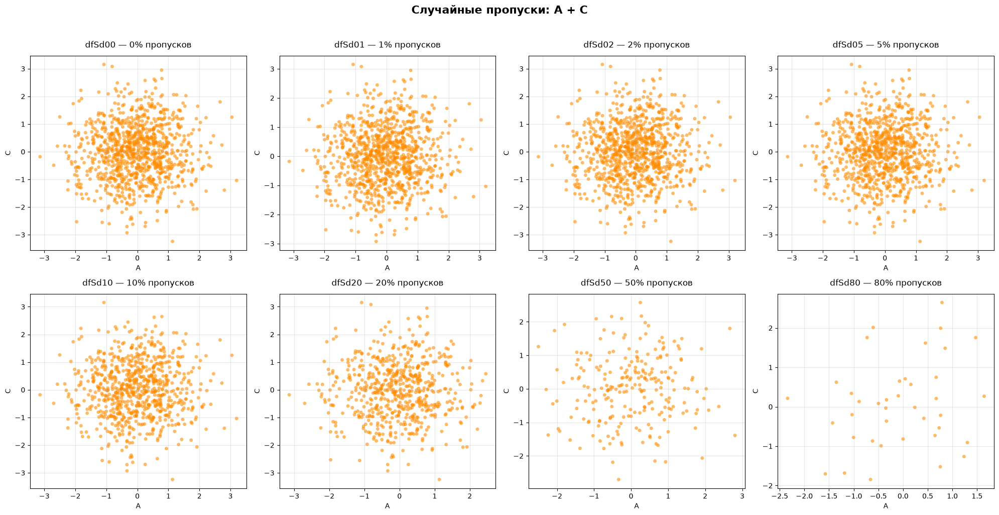

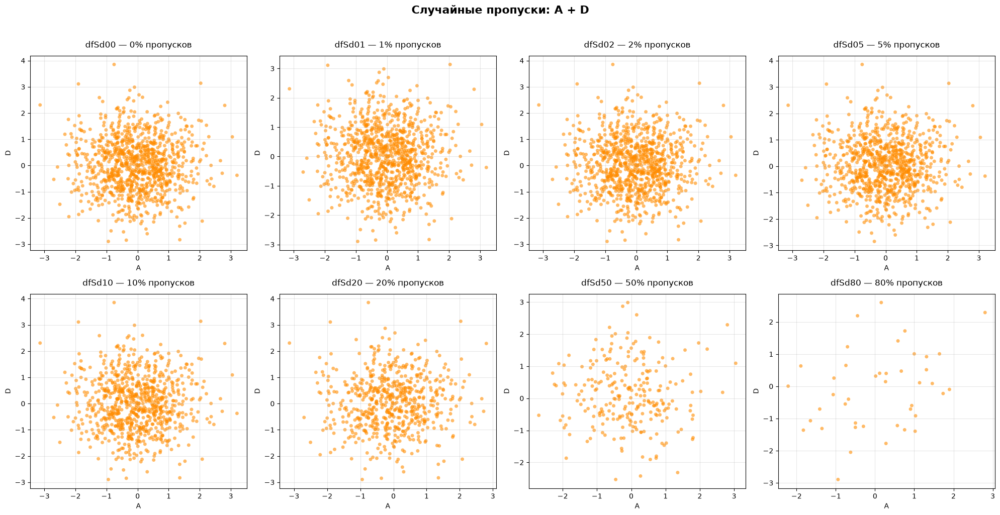

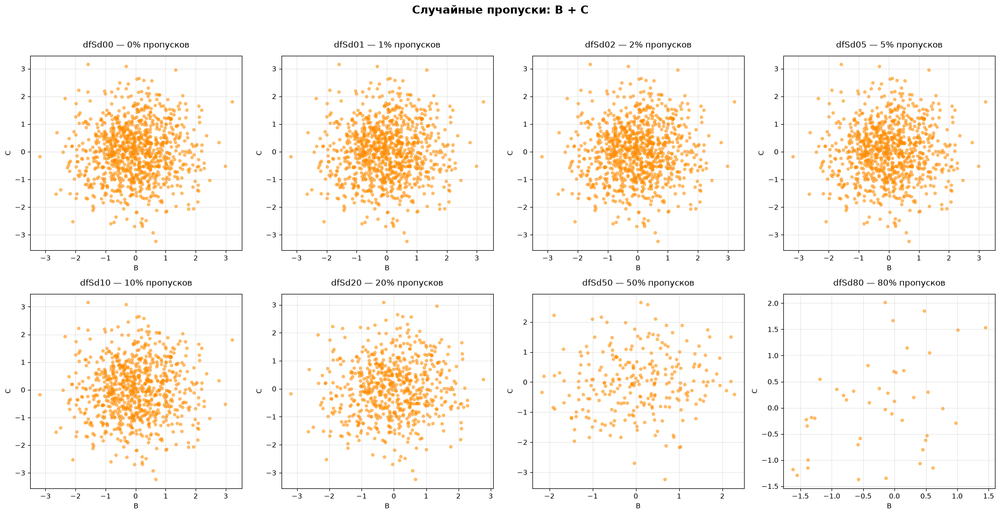

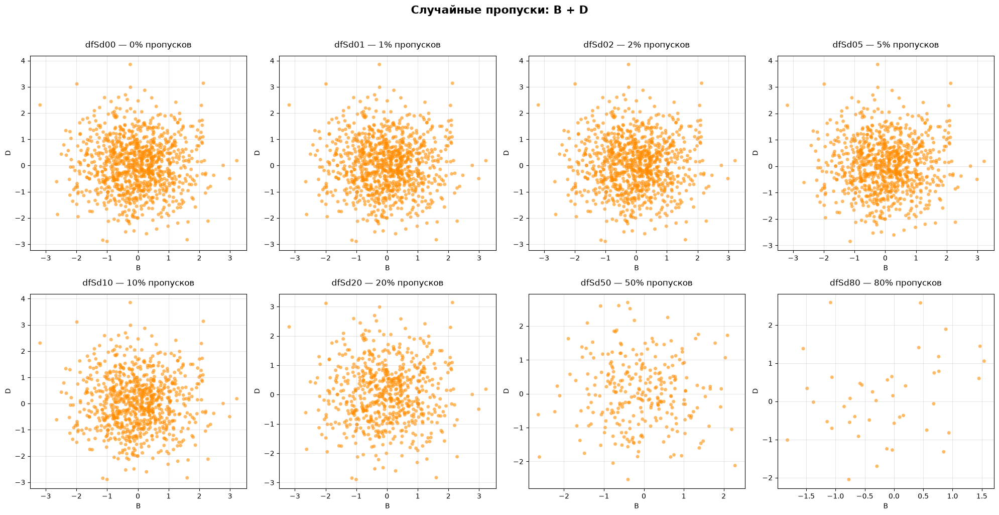

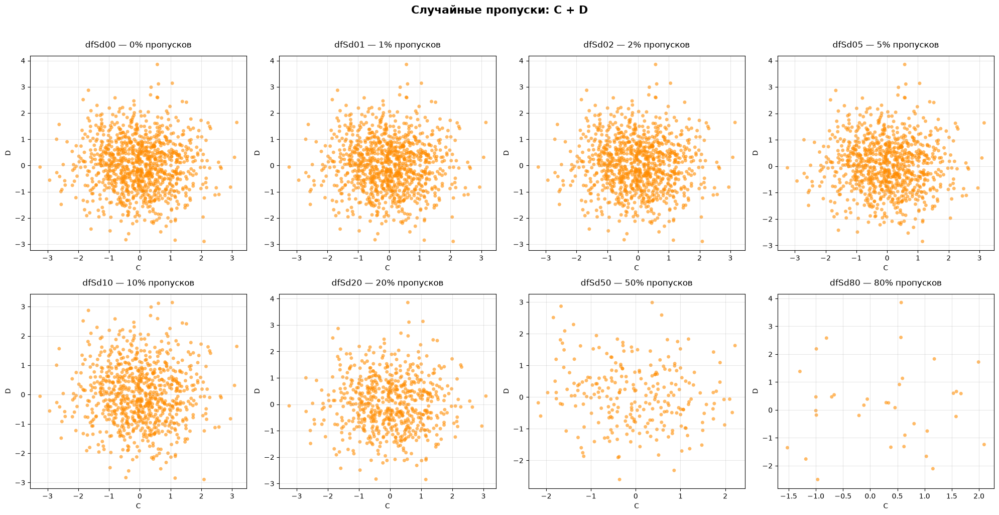

In [7]:
def add_random_missing_values(df, percent, features):
    df_out = df.copy()
    n_rows, n_cols = len(df), len(features)
    n = int(n_rows * n_cols * percent / 100)

    if n:
        idx = np.random.choice(n_rows * n_cols, n, replace=False)
        for i in idx:
            df_out.iat[i // n_cols, df.columns.get_loc(features[i % n_cols])] = np.nan
    return df_out

# Создаём dfSdXX для всех заданных процентов
percentages = [0, 1, 2, 5, 10, 20, 50, 80]
features = ['A', 'B', 'C', 'D']

datasets = {
    f'dfSd{p:02d}': add_random_missing_values(dfS00, p, features)
    for p in percentages
}

# Все необходимые пары признаков
pairs = list(combinations(features, 2))

for x, y in pairs:
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle(
        f'Случайные пропуски: {x} + {y}',
        fontsize=16,
        fontweight='bold',
        y=1.02
    )

    for ax, (name, df), p in zip(axes.flat, datasets.items(), percentages):
        sns.scatterplot(
            data=df, x=x, y=y, ax=ax,
            s=25, alpha=.6,
            color='darkorange',
            edgecolor='none'
        )

        ax.set_title(f'{name} — {p}% пропусков', y=1.02)
        ax.grid(True, alpha=.3)

    plt.tight_layout()
    plt.show()

## 7. Заполнение пропусков
- На  основе всех  датасетов  dfSdXX сгенерировать  соответствующие  датасеты dfSdXXmed,  в которых пропуски заполнены медианой
- Для выбираемой пары признаков (исходно  A+B)  визуализировать  панно  mxn  рисунков  scatterplot  для  всех  dfSdXXmed  и вывести как heatmap корреляции Пирсона как в пункте [1.5]

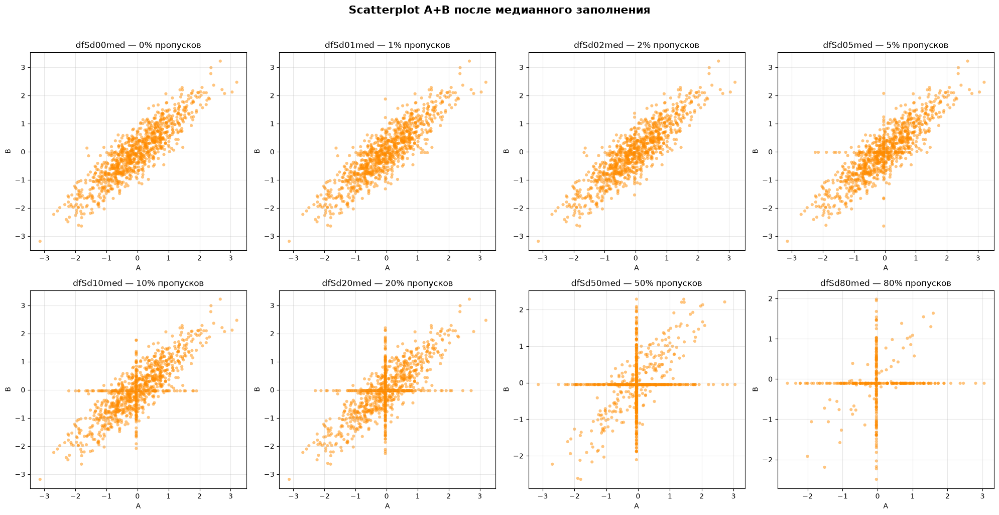

In [8]:
datasets_med = {}

for name, df in datasets.items():
    df_med = df.copy()
    df_med[features] = df_med[features].fillna(df_med[features].median())
    datasets_med[f'{name}med'] = df_med


# Панно 2×4 scatterplot для выбранной пары A+B
x_feature, y_feature = 'A', 'B'

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Scatterplot A+B после медианного заполнения',
             fontsize=16, fontweight='bold', y=1.02)

for ax, (name, df), p in zip(axes.flat, datasets_med.items(), percentages):
    sns.scatterplot(data=df, x=x_feature, y=y_feature, ax=ax,
                    s=20, alpha=.5, color='darkorange', edgecolor='none')
    ax.set_title(f'{name} — {p}% пропусков')
    ax.grid(True, alpha=.3)

plt.tight_layout()
plt.show()


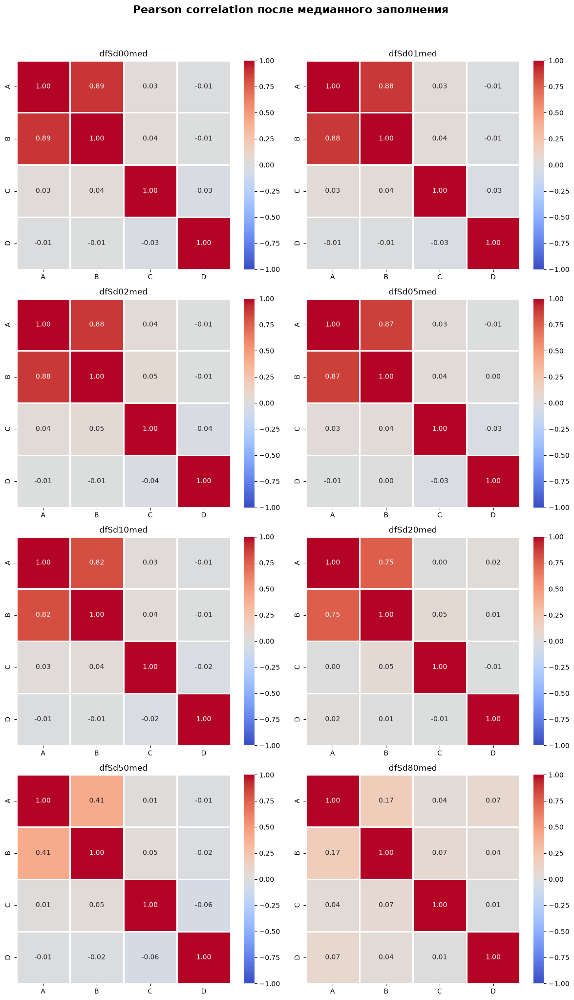

In [9]:
# Pearson heat-map для всех dfSdXXmed
fig, axes = plt.subplots(4, 2, figsize=(12, 20))
fig.suptitle('Pearson correlation после медианного заполнения',
             fontsize=16, fontweight='bold', y=1.02)

for ax, (name, df) in zip(axes.flat, datasets_med.items()):
    corr = df[features].corr(method='pearson')
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                center=0, fmt='.2f', linewidths=1, linecolor='white', ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 8. Заполнение пропусков разными методами
На основе одного из датасетов  dfSdXX, выбранного  пользователем,  сгенерировать соответствующие  датасеты  dfSdXXname,  в  котором  пропуски  заполнены  следующими методами  (name):  
- медианами
- kNN-заполнением
- регрессионным  заполнением
- MICE-заполнением. 

Для  dfSd00,  выбранного dfSdXX и  каждого  из  датасетов  dfSdXXname вывести как heatmap корреляции Пирсона как в пункте [1.5], а также визуализировать две пары  признаков, выбираемые  пользователем (исходно A+B  и C+D), как два панно mxn рисунков scatterplot. 

/home/fedosdan2/miniconda3/envs/sdt/lib/python3.12/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


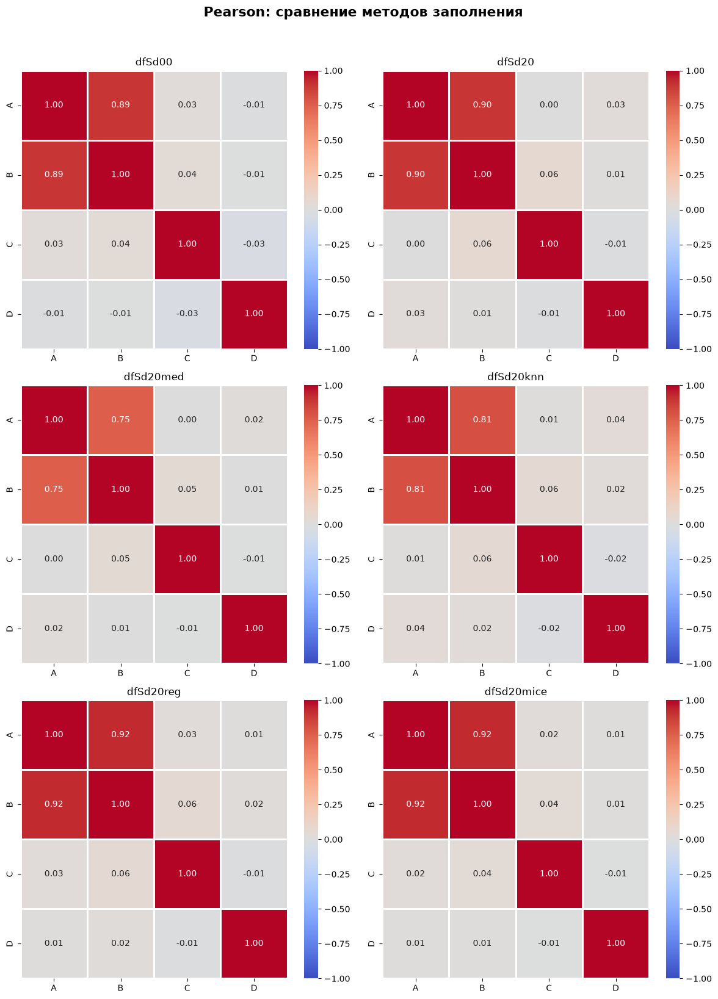

In [10]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge

# Пользователь выбирает dfSdXX
CHOSEN_PERCENT = 20
features = ['A', 'B', 'C', 'D']
chosen_name = f'dfSd{CHOSEN_PERCENT:02d}'
dfSd_chosen = datasets[chosen_name]

# Исходный, выбранный с пропусками и заполненные варианты
imputed_datasets = {
    'dfSd00': dfS00,
    chosen_name: dfSd_chosen
}

# 1. Медиана
df_med = dfSd_chosen.copy()
df_med[features] = SimpleImputer(strategy='median').fit_transform(df_med[features])
imputed_datasets[f'{chosen_name}med'] = df_med

# 2. kNN
df_knn = dfSd_chosen.copy()
df_knn[features] = KNNImputer(n_neighbors=5).fit_transform(df_knn[features])
imputed_datasets[f'{chosen_name}knn'] = df_knn

# 3. Регрессионное заполнение
df_reg = dfSd_chosen.copy()
df_reg[features] = IterativeImputer(
    estimator=LinearRegression(), max_iter=10, random_state=42
).fit_transform(df_reg[features])
imputed_datasets[f'{chosen_name}reg'] = df_reg

# 4. MICE
df_mice = dfSd_chosen.copy()
df_mice[features] = IterativeImputer(
    estimator=BayesianRidge(), 
    max_iter=20, 
    sample_posterior=False,
    initial_strategy='median',
    random_state=42
).fit_transform(df_mice[features])
imputed_datasets[f'{chosen_name}mice'] = df_mice


# ----------------------------------------------------------
# Pearson heat-map для всех вариантов
# ----------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
fig.suptitle('Pearson: сравнение методов заполнения', fontsize=16, fontweight='bold', y=1.02)

for ax, (name, df) in zip(axes.flat, imputed_datasets.items()):
    sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm',
                vmin=-1, vmax=1, center=0, fmt='.2f',
                linewidths=1, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()


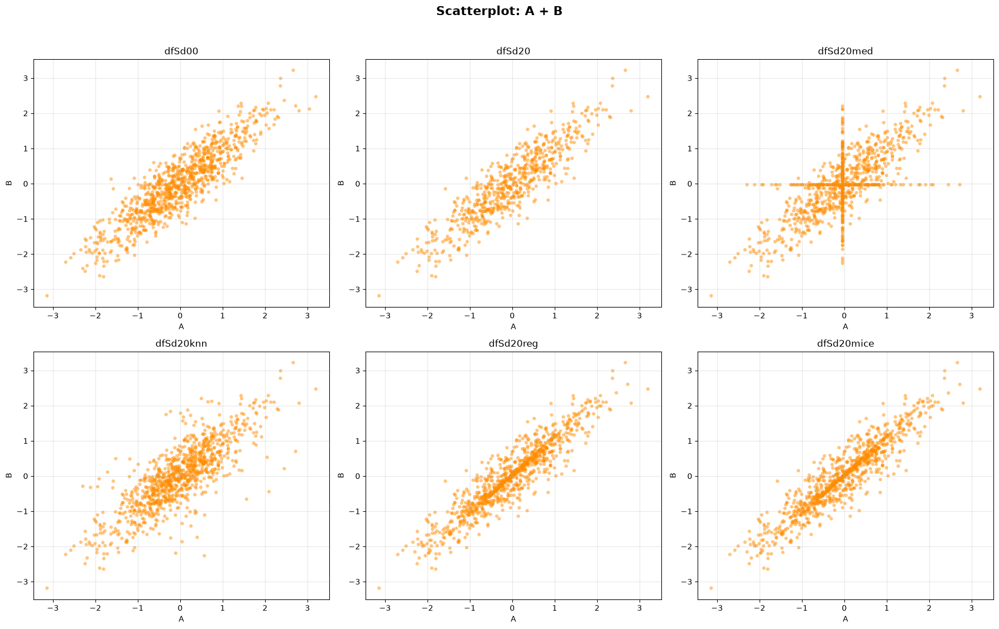

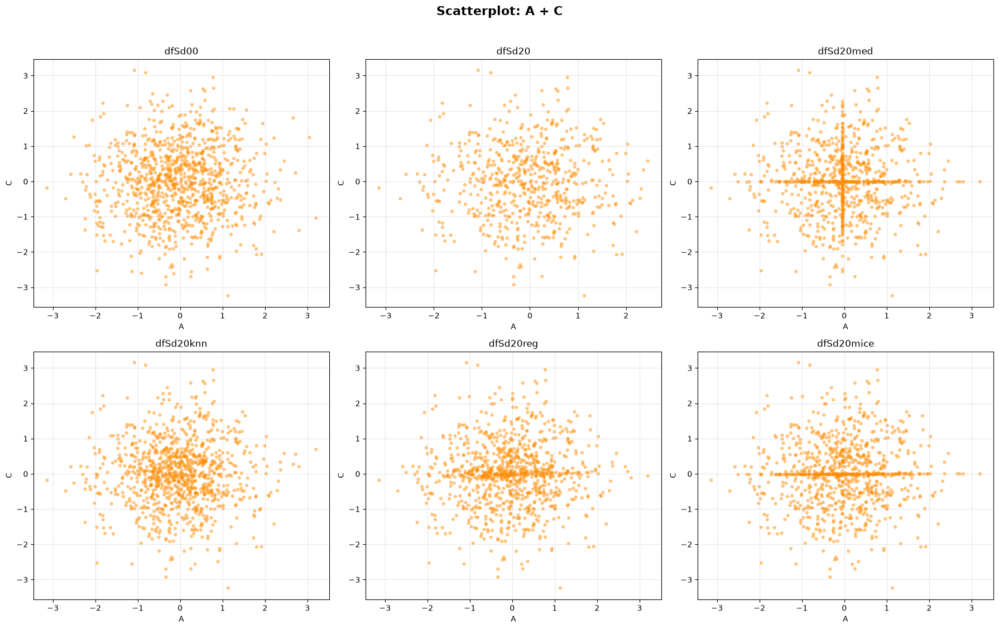

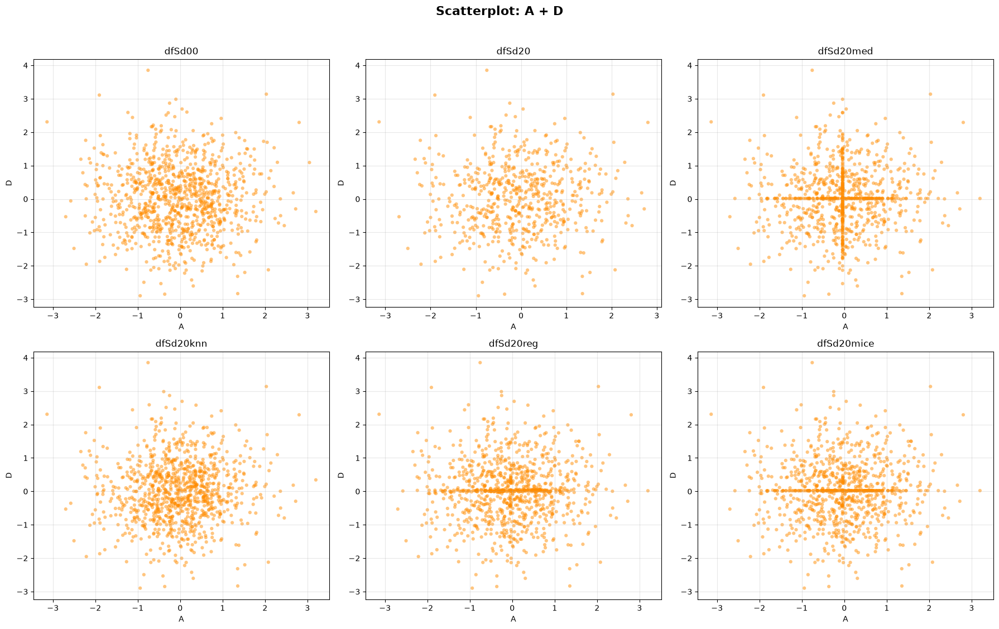

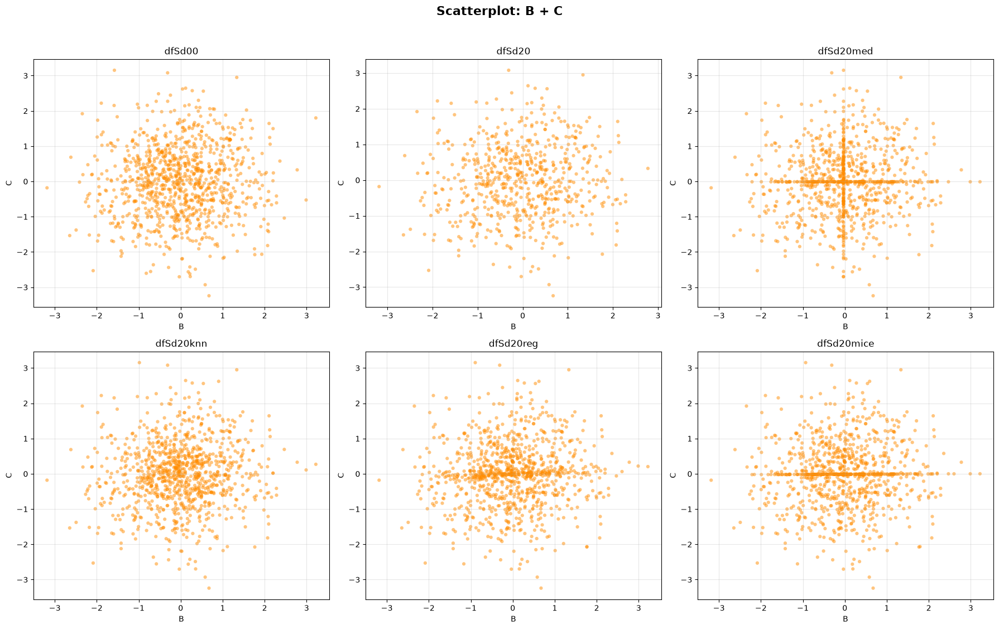

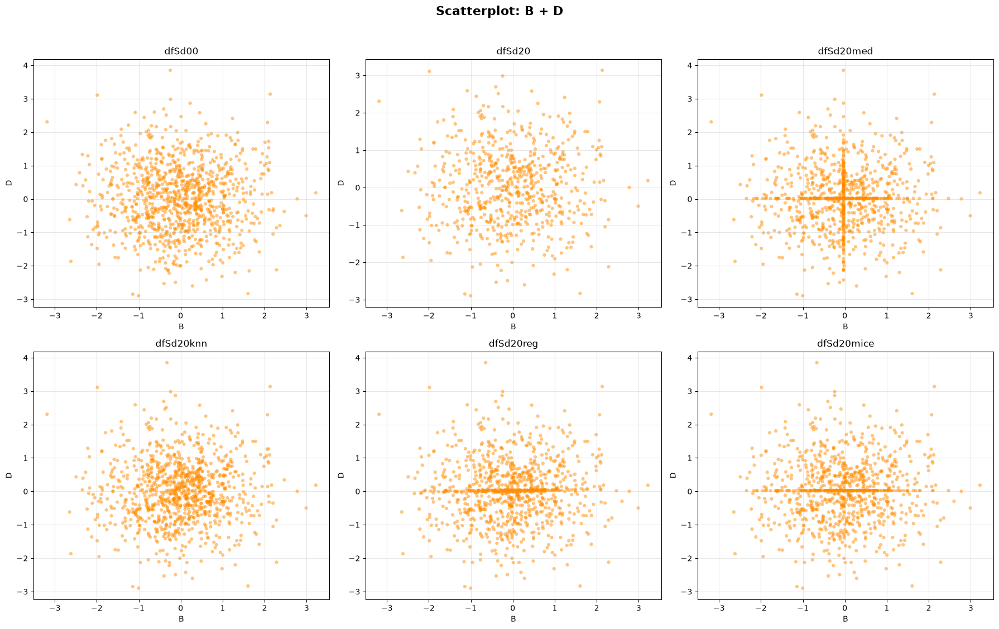

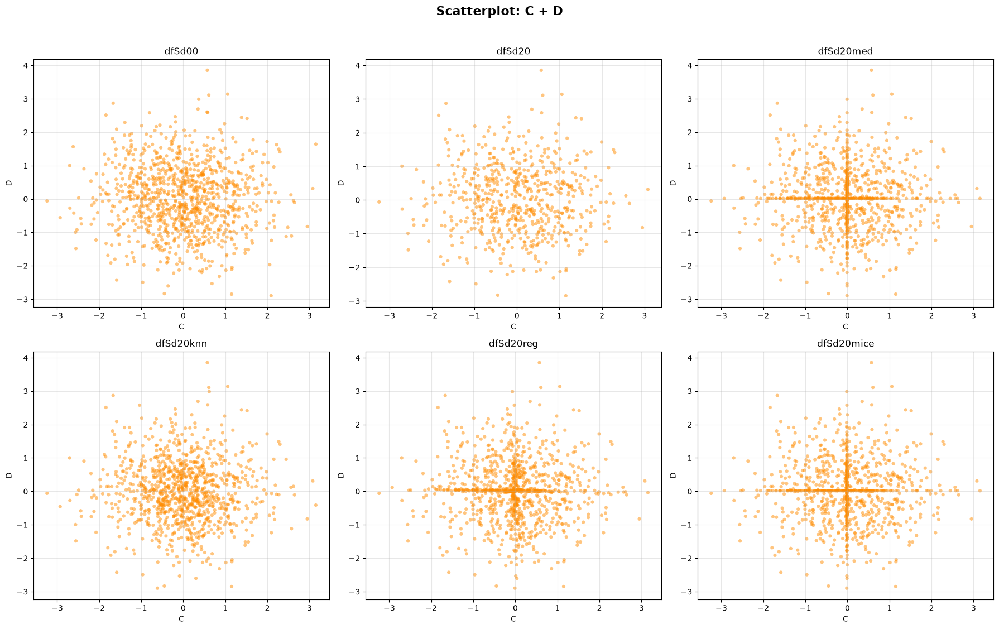

In [11]:
pairs = list(combinations(features, 2))

for x, y in pairs:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f'Scatterplot: {x} + {y}', fontsize=16, fontweight='bold', y=1.02)

    for ax, (name, df) in zip(axes.flat, imputed_datasets.items()):
        sns.scatterplot(data=df, x=x, y=y, ax=ax,
                        s=20, alpha=.5, color='darkorange', edgecolor='none')
        ax.set_title(name)
        ax.grid(True, alpha=.3)

    plt.tight_layout()
    plt.show()

## 9. Визуализация с помощью Upset Plot
Для каждого из датасетов из пункта  [1.8], включая исходный dfSd00, выполнить в форме  Upset  plot  визуализацию:
- чисел  объектов  с  пропущенными  значениями  для всех  вариантов  группировки  пропусков  по  признакам
- чисел  объектов  с совпадающими значениями по признакам для всех вариантов группировки признаков. 

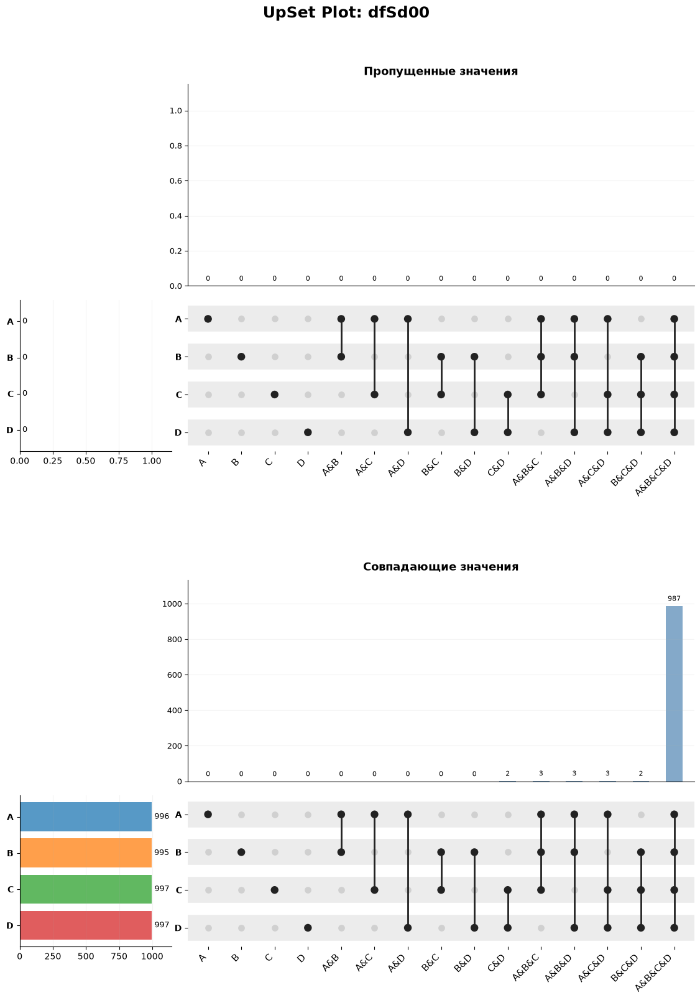

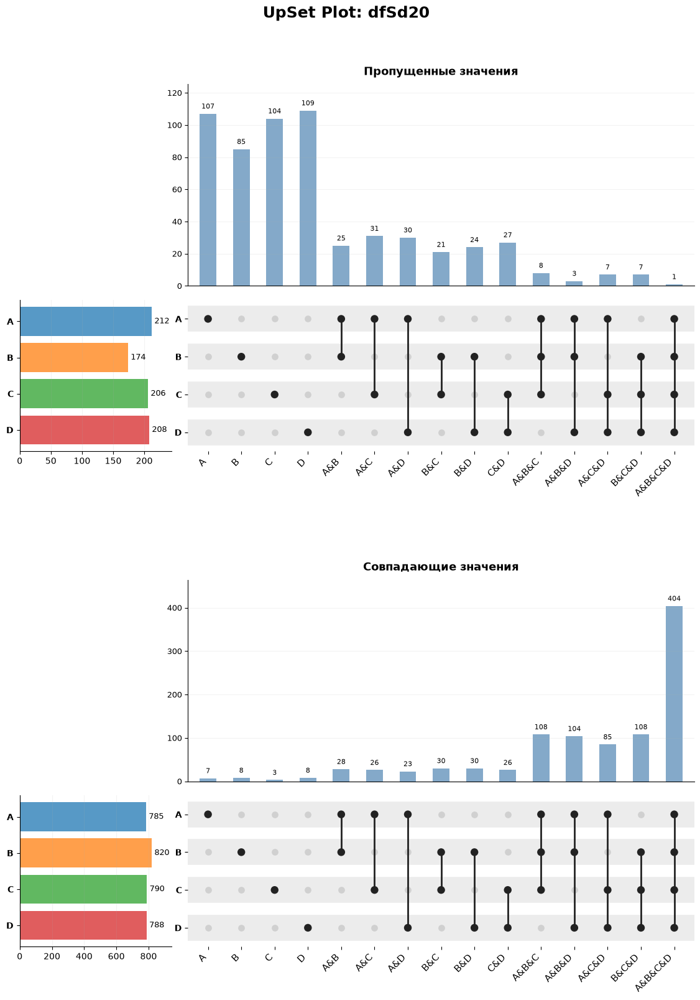

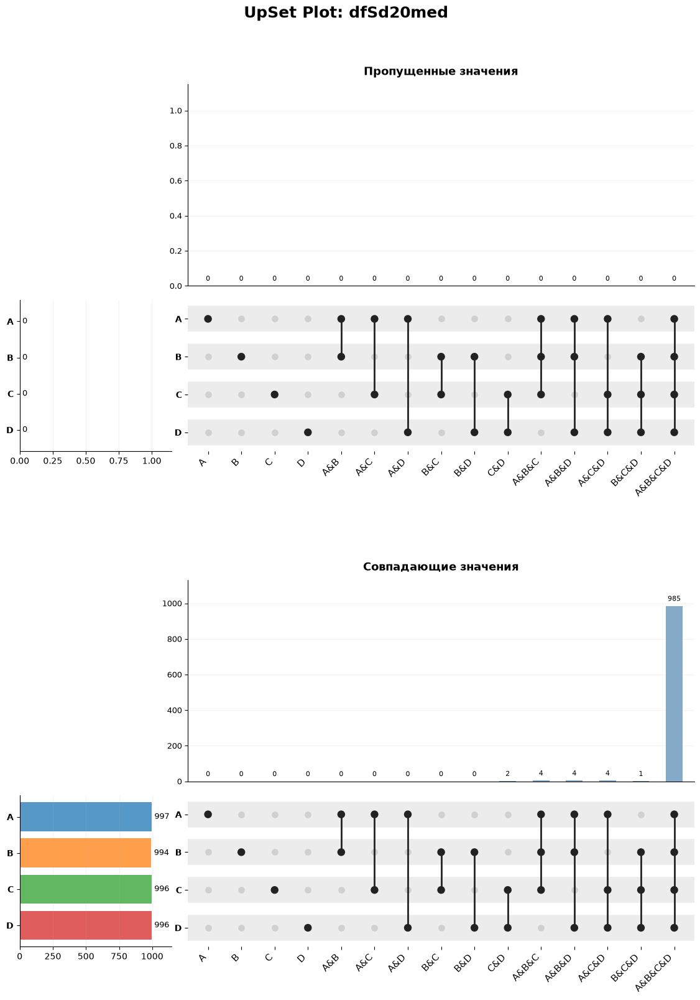

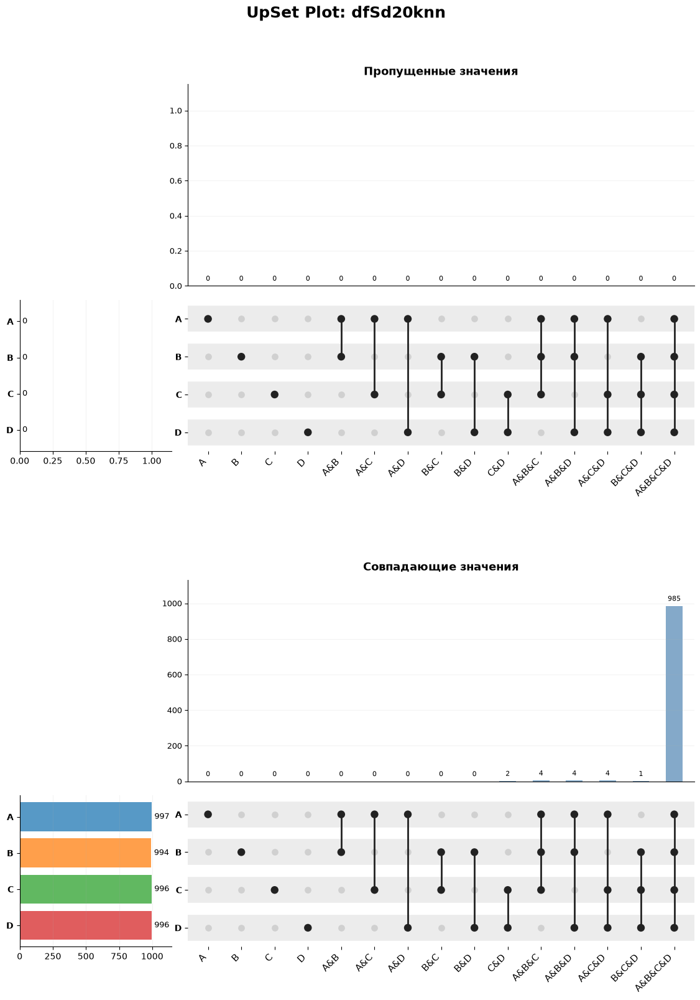

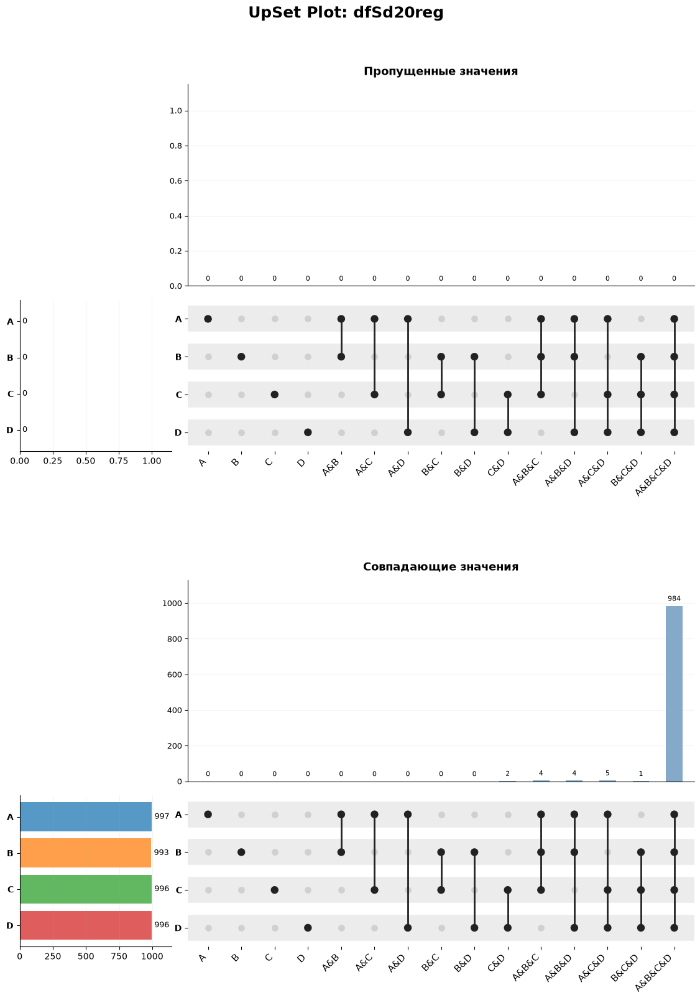

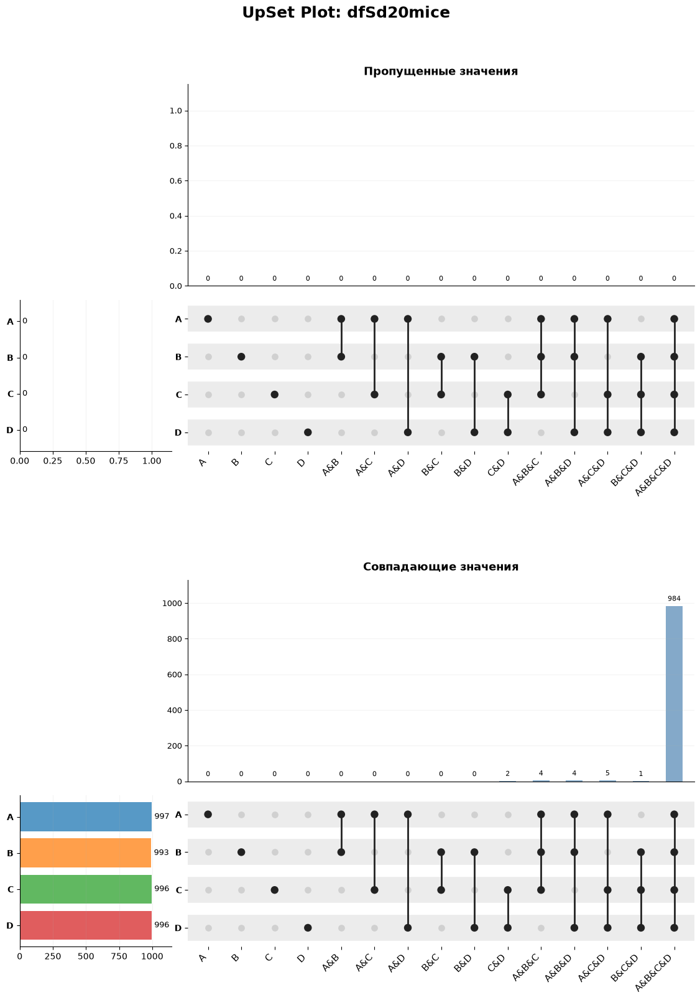

In [12]:
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FEATURE_COLORS = {
    'A': '#1f77b4',
    'B': '#ff7f0e',
    'C': '#2ca02c',
    'D': '#d62728'
}

features = ['A', 'B', 'C', 'D']

def compute_intersections(df, indicator_cols):
    intersections = {}
    for r in range(1, len(indicator_cols) + 1):
        for combo in combinations(range(len(indicator_cols)), r):
            selected = [indicator_cols[i] for i in combo]
            other = [col for i, col in enumerate(indicator_cols) if i not in combo]
            mask = df[selected].all(axis=1)
            if other:
                mask &= ~df[other].any(axis=1)
            intersections[combo] = mask.sum()
    return intersections

def similar_values_mask(series, tolerance=0.01):
    values = series.to_numpy(dtype=float)
    mask = np.zeros(len(values), dtype=bool)
    valid = np.isfinite(values)
    indices = np.where(valid)[0]
    if len(indices) < 2:
        return mask
    order = indices[np.argsort(values[indices])]
    sorted_values = values[order]
    close = np.diff(sorted_values) < tolerance
    mask[order[:-1][close]] = True
    mask[order[1:][close]] = True
    return mask

def plot_upset_axes(fig, gs, intersections, title, set_labels):
    combinations_list = list(intersections.keys())
    values = np.array([intersections[c] for c in combinations_list])
    x = np.arange(len(combinations_list))
    max_value = max(values.max(), 1)

    subgs = gs.subgridspec(
        2, 2,
        width_ratios=[1.5, 5],
        height_ratios=[4, 3],
        wspace=0.05,
        hspace=0.08
    )

    ax_set = fig.add_subplot(subgs[1, 0])
    ax_bar = fig.add_subplot(subgs[0, 1])
    ax_matrix = fig.add_subplot(subgs[1, 1])

    # Верхняя гистограмма пересечений
    ax_bar.bar(
        x, values,
        width=0.5,
        color='#5b8db8',
        alpha=0.75,
        edgecolor='none'
    )

    for i, value in enumerate(values):
        ax_bar.text(
            i,
            value + max_value * 0.02,
            str(value),
            ha='center',
            va='bottom',
            fontsize=8
        )

    ax_bar.set_title(
        title,
        fontsize=13,
        fontweight='bold',
        loc='center',
        y=1.02
    )

    ax_bar.set_xlim(-0.6, len(x) - 0.4)
    ax_bar.set_ylim(0, max_value * 1.15)
    ax_bar.set_xticks([])

    ax_bar.tick_params(
        axis='y',
        labelsize=9
    )

    ax_bar.spines[['top', 'right']].set_visible(False)
    ax_bar.grid(axis='y', alpha=0.15)

    # Левая часть — количество объектов в каждом признаке
    set_counts = []

    for feature in set_labels:
        set_counts.append(
            sum(
                value
                for combo, value in intersections.items()
                if features.index(feature) in combo
            )
        )

    y = np.arange(len(set_labels))

    ax_set.barh(
        y,
        set_counts,
        color=[FEATURE_COLORS[f] for f in set_labels],
        alpha=0.75,
        edgecolor='none'
    )

    ax_set.set_yticks(y)
    ax_set.set_yticklabels(
        set_labels,
        fontsize=10,
        fontweight='bold'
    )

    ax_set.invert_yaxis()
    ax_set.set_xlim(0, max(set_counts + [1]) * 1.15)

    ax_set.spines[['top', 'right']].set_visible(False)
    ax_set.grid(axis='x', alpha=0.15)

    for i, value in enumerate(set_counts):
        ax_set.text(
            value + max(set_counts + [1]) * 0.02,
            i,
            str(value),
            va='center',
            fontsize=9
        )

    # Матрица комбинаций
    ax_matrix.set_xlim(-0.6, len(x) - 0.4)
    ax_matrix.set_ylim(-0.5, len(set_labels) - 0.5)
    ax_matrix.invert_yaxis()

    for row in range(len(set_labels)):
        ax_matrix.axhline(
            row,
            color='gray',
            alpha=0.15,
            linewidth=30
        )

    # Серые базовые точки
    for i in x:
        for row in range(len(set_labels)):
            ax_matrix.scatter(
                i,
                row,
                s=45,
                color='#d0d0d0',
                zorder=2
            )

    # Активные точки и соединения
    for i, combo in enumerate(combinations_list):
        rows = list(combo)

        if len(rows) > 1:
            ax_matrix.plot(
                [i, i],
                [min(rows), max(rows)],
                color='#222222',
                linewidth=2,
                zorder=3
            )

        for row in rows:
            ax_matrix.scatter(
                i,
                row,
                s=80,
                color='#222222',
                edgecolor='none',
                zorder=4
            )

    ax_matrix.set_yticks(np.arange(len(set_labels)))
    ax_matrix.set_yticklabels(
        set_labels,
        fontsize=10,
        fontweight='bold'
    )
    ax_matrix.set_xticks(x)

    labels = [
        '&'.join(set_labels[i] for i in combo)
        for combo in combinations_list
    ]

    ax_matrix.set_xticklabels(
        labels,
        rotation=45,
        ha='right',
        fontsize=11
    )

    ax_matrix.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    return ax_set, ax_bar, ax_matrix

def plot_one_dataset_panel(df, dataset_name):
    # 1. Пропуски
    missing_flags = df[features].isna()
    missing_intersections = compute_intersections(
        missing_flags,
        features
    )

    # 2. Совпадающие значения
    similar_flags = pd.DataFrame({
        feature: similar_values_mask(df[feature], tolerance=0.1)
        for feature in features
    })

    similar_intersections = compute_intersections(
        similar_flags,
        features
    )

    fig = plt.figure(figsize=(14, 18))

    outer = fig.add_gridspec(
        2, 1,
        height_ratios=[1, 1],
        hspace=0.35
    )

    plot_upset_axes(
        fig,
        outer[0],
        missing_intersections,
        f'Пропущенные значения',
        features
    )

    plot_upset_axes(
        fig,
        outer[1],
        similar_intersections,
        f'Совпадающие значения',
        features
    )

    fig.suptitle(
        f'UpSet Plot: {dataset_name}',
        fontsize=18,
        fontweight='bold',
        y=0.95
    )

    plt.show()

#----------------------------------------------
features = ['A', 'B', 'C', 'D']
abbrevs = ['A', 'B', 'C', 'D']

datasets = imputed_datasets.copy()
if 'dfSd00' not in datasets:
    datasets['dfS00'] = dfS00

for name, df in datasets.items():

    plot_one_dataset_panel(df, name)

## 10. Работа с dfMNAR
- На основе исходного датасета dfS00 клонировать датасет dfMNAR, в котором для каждого  объекта  удалены  все  значения  призаков  C  и  D,  которые  меньше  признаковой медианы.  
- Выполнить для полученного датасета пункты [1.8] и [1.9]. 

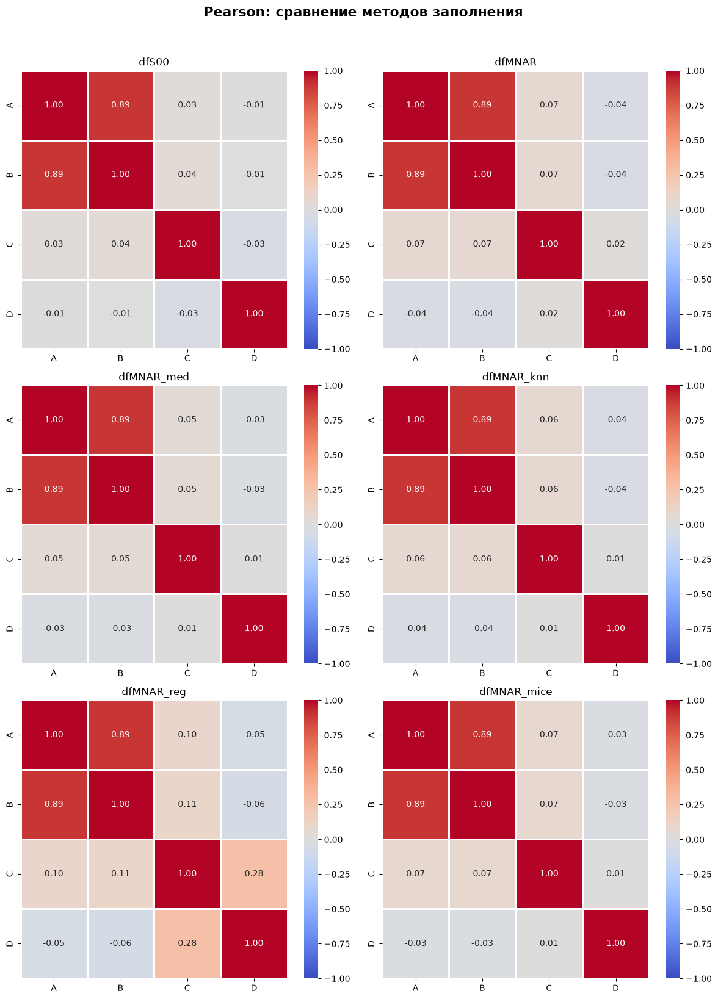

<Figure size 640x480 with 0 Axes>

In [17]:
features = ['A', 'B', 'C', 'D']
pairs = [('A', 'B'), ('C', 'D')]

dfMNAR = dfS00.copy()
for col in ['C', 'D']:
    dfMNAR.loc[dfMNAR[col] < dfMNAR[col].median(), col] = np.nan

# ===== [1.8] Заполнение пропусков =====
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import LinearRegression, BayesianRidge

mnar_datasets = {'dfS00':  dfS00,
                 'dfMNAR': dfMNAR}

# 1. Median
df = dfMNAR.copy()
df[features] = SimpleImputer(strategy='median').fit_transform(df[features])
mnar_datasets['dfMNAR_med'] = df

# 2. KNN
df = dfMNAR.copy()
df[features] = KNNImputer(n_neighbors=10).fit_transform(df[features])
mnar_datasets['dfMNAR_knn'] = df

# 3. REgression
df = dfMNAR.copy()
df[features] = IterativeImputer(
    estimator=LinearRegression(), 
    max_iter=20, 
    random_state=42
).fit_transform(df[features])
mnar_datasets['dfMNAR_reg'] = df

# 4. MICE 
df = dfMNAR.copy()
df[features] = IterativeImputer(
    estimator=BayesianRidge(), 
    max_iter=20, 
    sample_posterior=False,
    initial_strategy='median', 
    random_state=42
).fit_transform(df[features])
mnar_datasets['dfMNAR_mice'] = df


# Pearson heatmap
fig, axes = plt.subplots(3, 2, figsize=(12, 16))
fig.suptitle('Pearson: сравнение методов заполнения', fontsize=16, fontweight='bold', y=1.02)

for ax, (name, df) in zip(axes.flat, mnar_datasets.items()):
    sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm',
                vmin=-1, vmax=1, center=0, fmt='.2f',
                linewidths=1, ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()


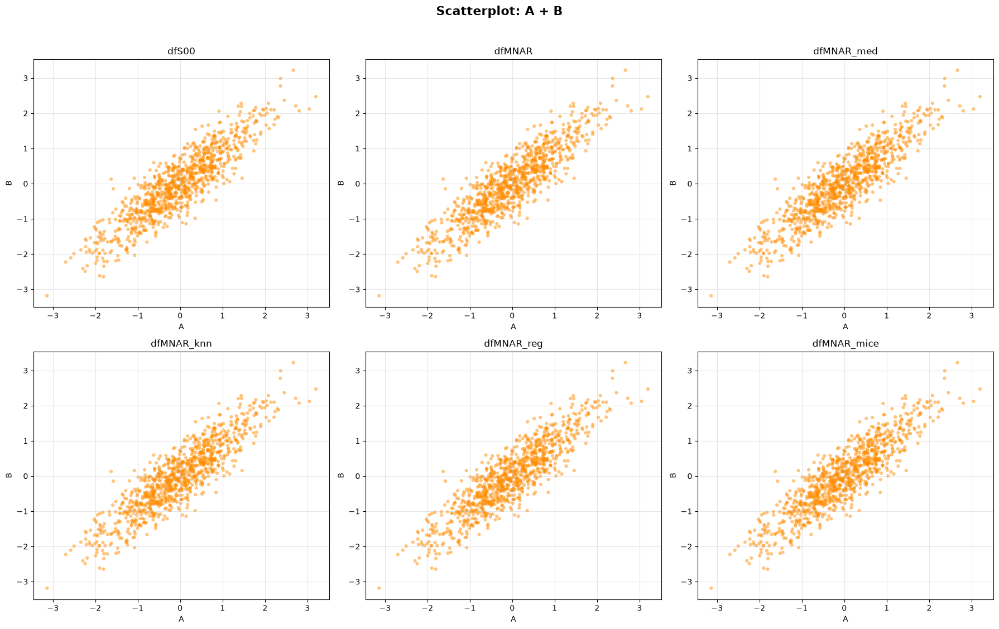

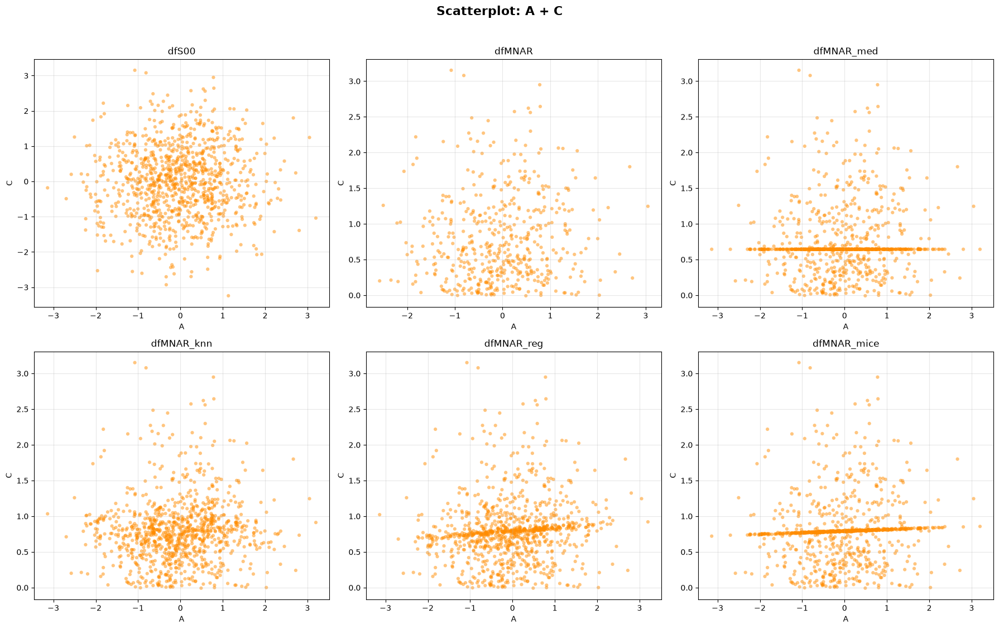

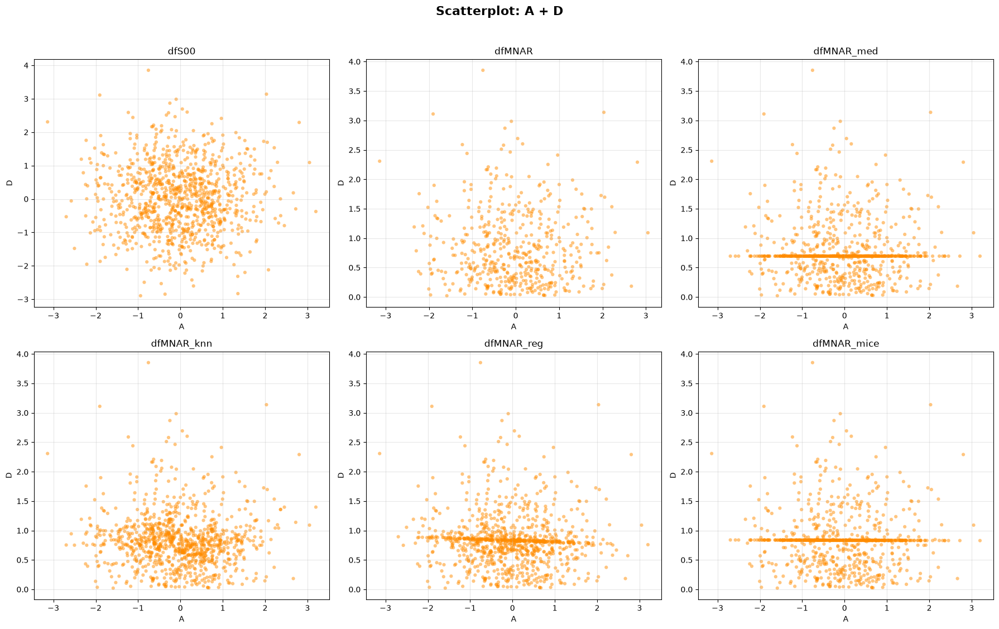

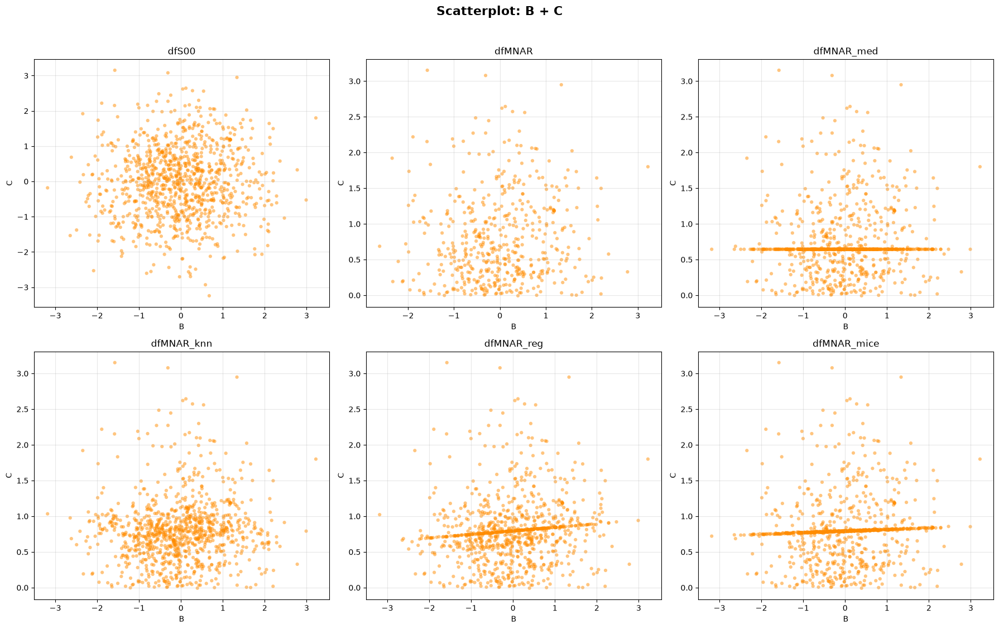

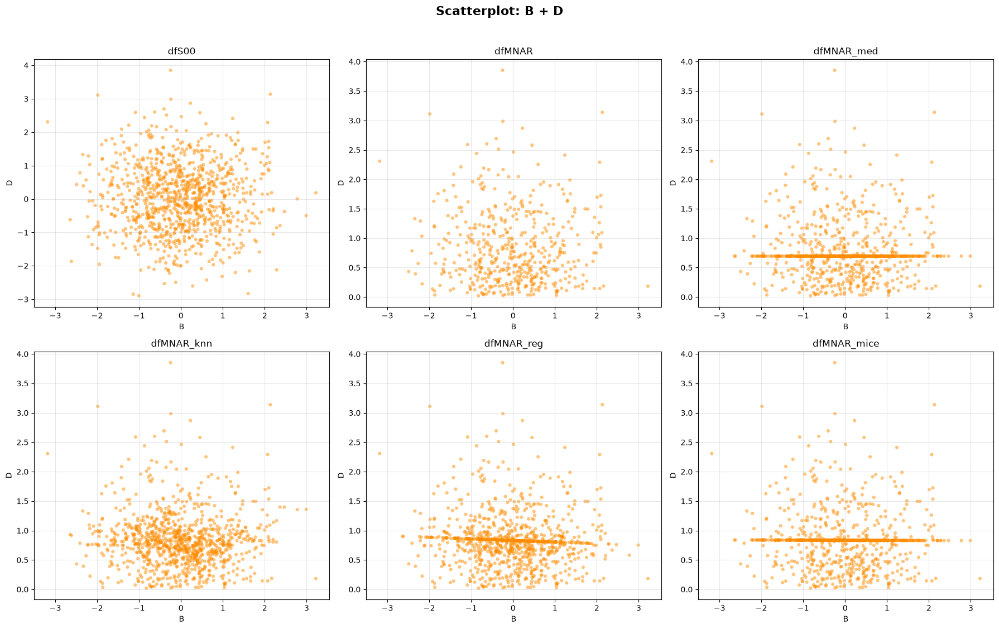

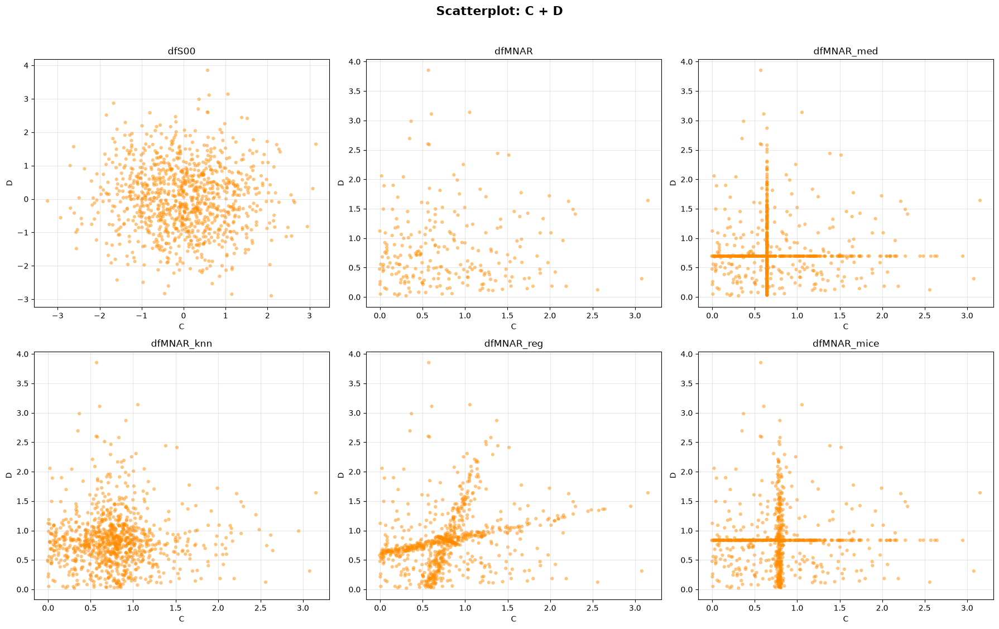

In [14]:
pairs = list(combinations(features, 2))

for x, y in pairs:
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f'Scatterplot: {x} + {y}', fontsize=16, fontweight='bold', y=1.02)

    for ax, (name, df) in zip(axes.flat, mnar_datasets.items()):
        sns.scatterplot(data=df, x=x, y=y, ax=ax,
                        s=20, alpha=.5, color='darkorange', edgecolor='none')
        ax.set_title(name)
        ax.grid(True, alpha=.3)

    plt.tight_layout()
    plt.show()

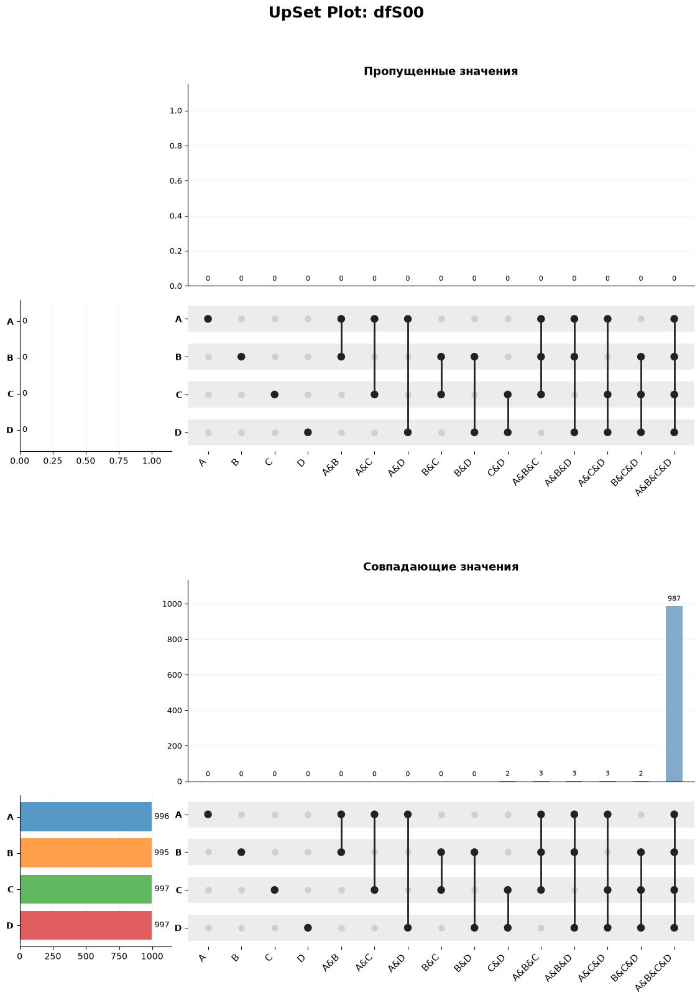

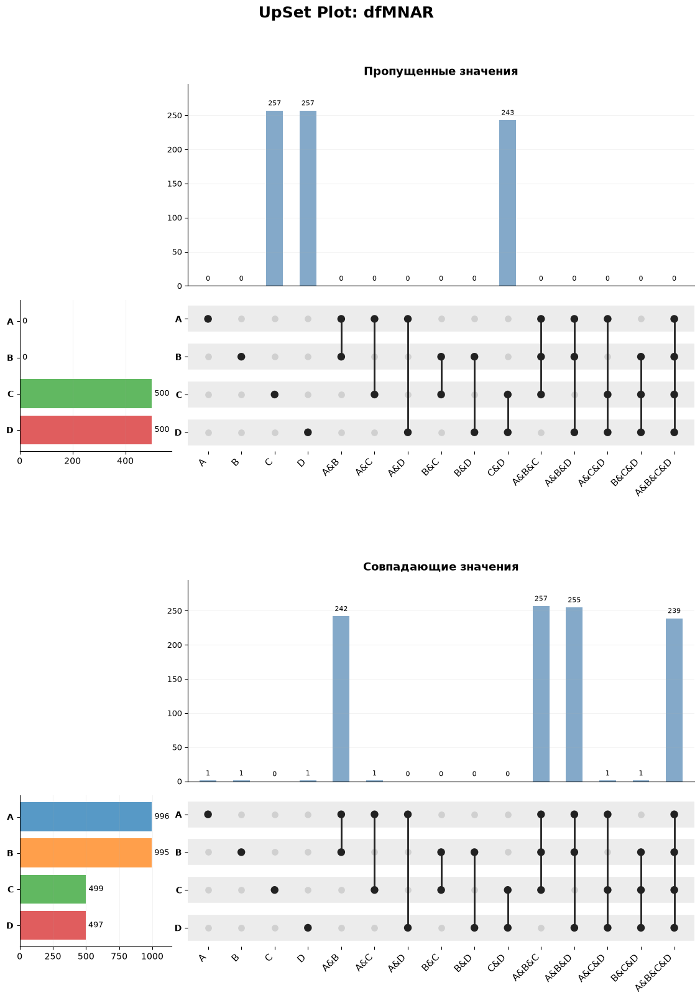

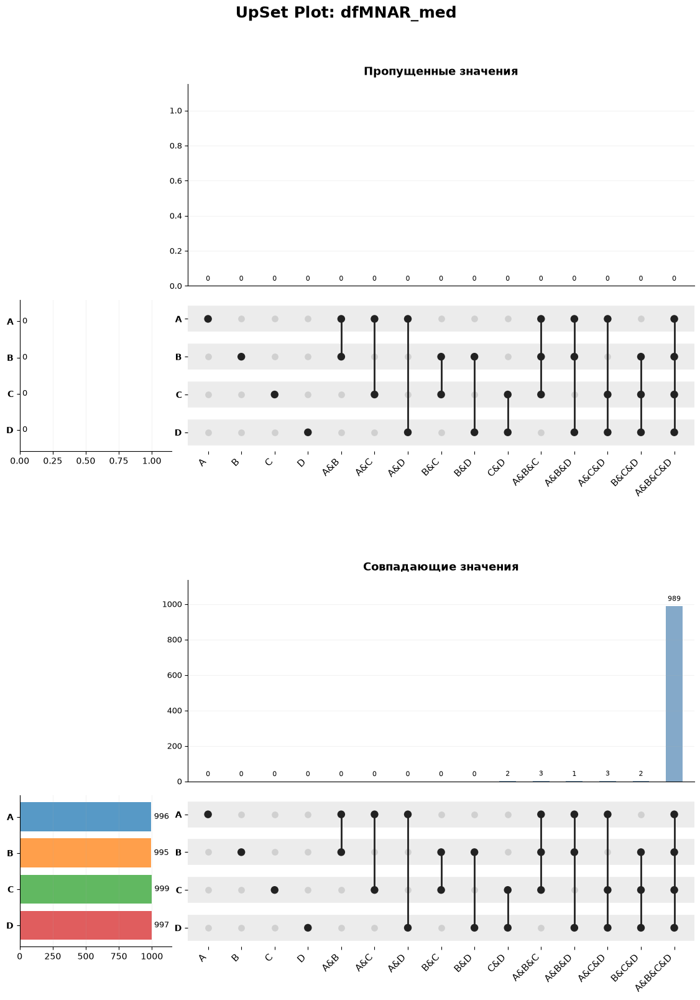

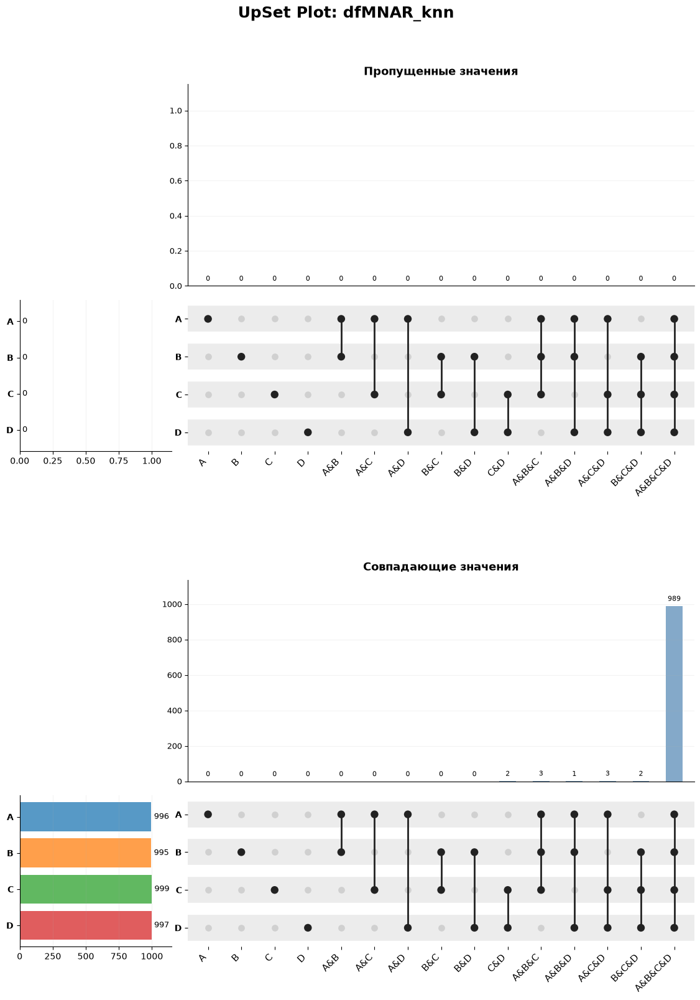

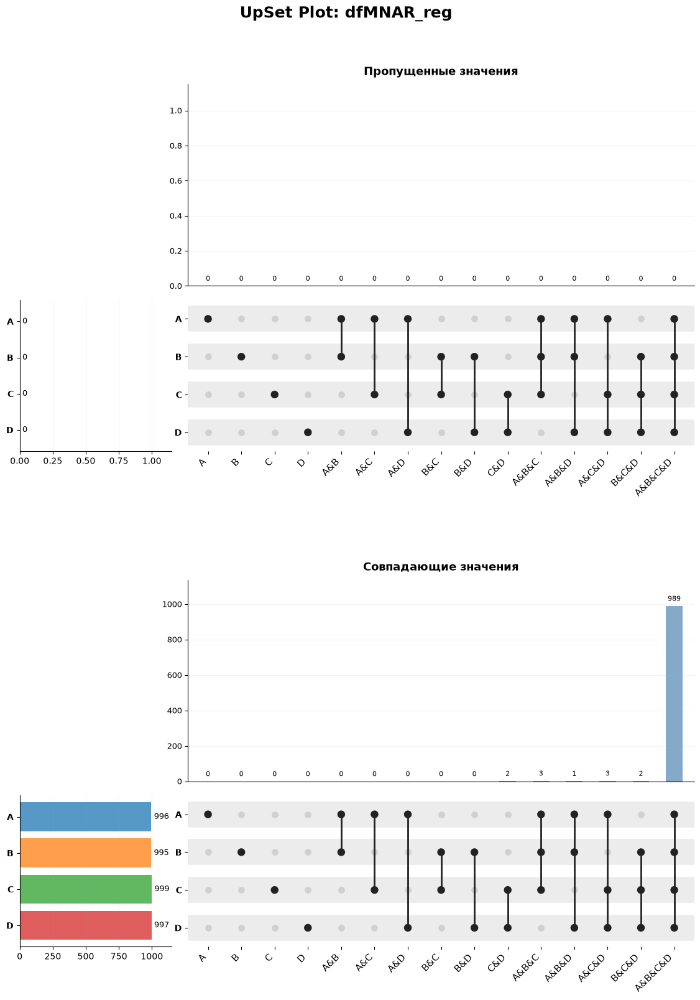

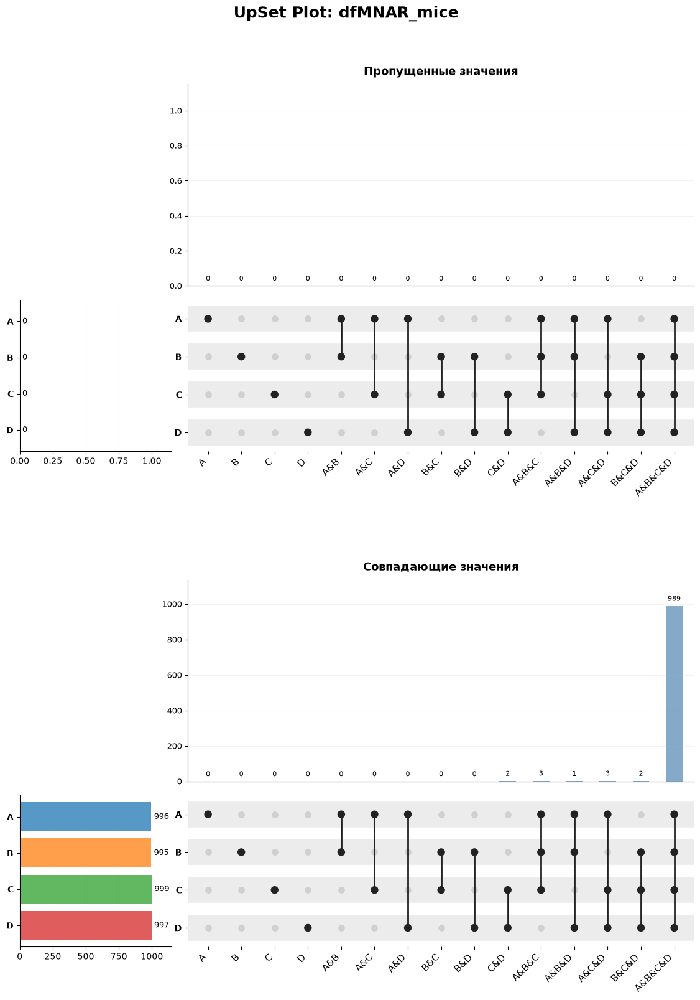

In [15]:
for name, df in mnar_datasets.items():
    plot_one_dataset_panel(df, name) 